# 10 - Synthetic benchmark v0.3: temporal/candidate revision validation

## tl;dr

Validates `v0_3_temporal_candidate_revision` against the conservative
readiness gate for linkage-algorithm evaluation. This notebook checks:

- conditional field fidelity did not regress materially from v0.2;
- temporal/follow-up gates still pass;
- production Layer 1 candidate environment now passes in the true algorithm
  source scope;
- structural truth still separates latent recurrence from candidate-window
  design.

No linkage scores, thresholds, accepted links, precision, or recall are used.


## Setup

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from boamp.config import load_config
from boamp.data.prepare import tag_digital_scope
from boamp.linkage.candidates import generate_pairs_single_key
from boamp.reporting.figures import setup_style
from boamp.synthetic.compatibility import adapt_observed_notices_to_sources
from utils.text_clean import normalize_objet

setup_style()
cfg = load_config(PROJECT_ROOT)

V2 = "v0_2_conditional_revision"
V3 = "v0_3_temporal_candidate_revision"
SCENARIO = "central_provisional"
VERSIONS = {
    V2: PROJECT_ROOT / "data/processed/synthetic_benchmark" / V2 / SCENARIO / "world_001/corruption_001",
    V3: PROJECT_ROOT / "data/processed/synthetic_benchmark" / V3 / SCENARIO / "world_001/corruption_001",
}

REAL_PATH = PROJECT_ROOT / "data/interim/boamp_common_prepared.csv"
REAL_SOURCES_PATH = PROJECT_ROOT / "data/processed/boamp_only/boamp_only_sources.csv"
REAL_PAIRS_PATH = PROJECT_ROOT / "data/processed/boamp_only/boamp_only_candidate_pairs.csv"

OUT_TABLES = PROJECT_ROOT / "reports/tables/synthetic_benchmark" / V3
OUT_FIGURES = PROJECT_ROOT / "reports/figures/synthetic_benchmark" / V3
OUT_REPORT = PROJECT_ROOT / "reports/generated/synthetic_benchmark/v0_3_temporal_candidate_revision_report.md"
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUT_REPORT.parent.mkdir(parents=True, exist_ok=True)

COLOR_REAL = "#2a78d6"
COLOR_V2 = "#9a9a95"
COLOR_V3 = "#eb6834"

ACCEPTANCE = {
    "conditional_wmae_pp_max": 3.0,
    "conditional_regression_pp_max": 1.0,
    "year_share_tvd_max": 0.20,
    "schema_by_year_wmae_pp_max": 3.0,
    "notice_type_by_year_wmae_pp_max": 5.0,
    "followup_12m_24m_abs_pp_max": 3.0,
    "candidate_source_count_ratio_min": 0.80,
    "candidate_source_count_ratio_max": 1.20,
    "candidate_zero_abs_pp_max": 5.0,
    "candidate_p75_abs_count_max": 3.0,
    "candidate_p90_abs_count_max": 5.0,
    "candidate_p95_abs_count_max": 8.0,
    "candidate_cap_rate_max": 0.01,
    "candidate_by_key_zero_abs_pp_max": 10.0,
    "truth_gap_gt6_share_min": 0.45,
}
pd.DataFrame([ACCEPTANCE]).to_csv(OUT_TABLES / "v0_3_readiness_acceptance_criteria.csv", index=False)
ACCEPTANCE

{'conditional_wmae_pp_max': 3.0,
 'conditional_regression_pp_max': 1.0,
 'year_share_tvd_max': 0.2,
 'schema_by_year_wmae_pp_max': 3.0,
 'notice_type_by_year_wmae_pp_max': 5.0,
 'followup_12m_24m_abs_pp_max': 3.0,
 'candidate_source_count_ratio_min': 0.8,
 'candidate_source_count_ratio_max': 1.2,
 'candidate_zero_abs_pp_max': 5.0,
 'candidate_p75_abs_count_max': 3.0,
 'candidate_p90_abs_count_max': 5.0,
 'candidate_p95_abs_count_max': 8.0,
 'candidate_cap_rate_max': 0.01,
 'candidate_by_key_zero_abs_pp_max': 10.0,
 'truth_gap_gt6_share_min': 0.45}

## Load Data

In [2]:
real = pd.read_csv(
    REAL_PATH,
    usecols=[
        "notice_id", "publication_date", "publication_year", "schema_family",
        "notice_type_normalized", "buyer_siret_clean", "cpv_clean", "cpv_division",
        "duration_raw", "objet_normalized", "objet_clean", "buyer_key",
    ],
    parse_dates=["publication_date"],
    low_memory=False,
)
real_sources = pd.read_csv(REAL_SOURCES_PATH, parse_dates=["publication_date", "estimated_end_date"])
real_pairs = pd.read_csv(REAL_PAIRS_PATH, parse_dates=["source_date", "candidate_date", "expected_end_date"])

observed = {version: pd.read_parquet(path / "observed_notices.parquet") for version, path in VERSIONS.items()}
clean_v3 = pd.read_parquet(VERSIONS[V3] / "clean_notices.parquet")
relations_v3 = pd.read_parquet(VERSIONS[V3] / "true_relations.parquet")
metadata_v3 = json.loads((VERSIONS[V3] / "generation_metadata.json").read_text())

for df in observed.values():
    df["publication_date"] = pd.to_datetime(df["publication_date"])
clean_v3["publication_date_true"] = pd.to_datetime(clean_v3["publication_date_true"])

pd.DataFrame(
    {
        "dataset": ["real", V2, V3],
        "n_rows": [len(real), len(observed[V2]), len(observed[V3])],
        "metadata_status": ["source", "existing", metadata_v3["validation_status"]],
    }
)

,dataset,n_rows,metadata_status
0,real,84623,source
1,v0_2_conditional_revision,9607,existing
2,v0_3_temporal_candidate_revision,9471,PASS


## Conditional Field Fidelity

In [3]:
REAL_USECOLS = [
    "notice_id", "schema_family", "notice_type_normalized", "publication_year",
    "buyer_siret_clean", "cpv_clean", "cpv_division", "duration_raw",
    "objet_normalized", "objet_clean", "buyer_key",
]


def add_common_flags(frame: pd.DataFrame, id_col: str) -> pd.DataFrame:
    out = frame.copy()
    counts = out.groupby("buyer_key", dropna=False)[id_col].transform("size")
    out["buyer_activity_tier"] = pd.cut(
        counts, bins=[0, 1, 5, 20, np.inf],
        labels=["1 (single)", "2-5", "6-20", "21+"],
        right=True,
    ).astype(str)
    text_stats = (
        out.dropna(subset=["objet_normalized"])
        .groupby("objet_normalized")
        .agg(n_notices=("objet_normalized", "size"), n_buyers=("buyer_key", "nunique"))
    )
    generic_texts = set(text_stats.query("n_notices >= 2 and n_buyers >= 2").index)
    out["generic_text"] = out["objet_normalized"].isin(generic_texts)
    out["siret_present"] = out["buyer_siret_clean"].notna()
    out["cpv_missing"] = out["cpv_clean"].isna()
    out["duration_present"] = out["duration_raw"].notna()
    return out


real_conditional = add_common_flags(real[REAL_USECOLS].copy(), "notice_id")


def load_synthetic_conditional(version: str) -> pd.DataFrame:
    obs = observed[version]
    adapted = adapt_observed_notices_to_sources(obs)
    adapted["publication_year"] = pd.to_datetime(adapted["publication_date"]).dt.year
    adapted["duration_raw"] = obs["declared_duration_months"]
    adapted["objet_normalized"] = adapted["objet_clean"].map(normalize_objet)
    return add_common_flags(adapted, "notice_id")


synthetic_conditional = {version: load_synthetic_conditional(version) for version in [V2, V3]}


def rates(frame: pd.DataFrame, outcome: str, group_cols: list[str]) -> pd.DataFrame:
    out = frame.groupby(group_cols, dropna=False)[outcome].agg(successes="sum", n="count").reset_index()
    out["rate"] = out["successes"] / out["n"]
    return out


def compare_version(version: str, outcome: str, group_cols: list[str], target: str) -> pd.DataFrame:
    real_rates = rates(real_conditional, outcome, group_cols)
    syn_rates = rates(synthetic_conditional[version], outcome, group_cols)
    comp = real_rates.merge(syn_rates, on=group_cols, how="outer", suffixes=("_real", "_synthetic"))
    comp.insert(0, "version", version)
    comp.insert(1, "target", target)
    comp["diff_pp"] = (comp["rate_synthetic"] - comp["rate_real"]) * 100
    comp["abs_diff_pp"] = comp["diff_pp"].abs()
    comp["eligible_cell"] = comp["n_real"].fillna(0).ge(30) & comp["n_synthetic"].fillna(0).ge(30)
    return comp


TARGETS = {
    "siret_present": ("siret_present", ["schema_family", "publication_year", "notice_type_normalized"]),
    "duration_present": ("duration_present", ["schema_family", "publication_year", "notice_type_normalized"]),
    "cpv_missing": ("cpv_missing", ["schema_family", "notice_type_normalized"]),
    "generic_repeated_text": ("generic_text", ["notice_type_normalized", "buyer_activity_tier"]),
}


def summarize(comp: pd.DataFrame) -> pd.Series:
    eligible = comp[comp["eligible_cell"]].copy()
    real_total = comp["n_real"].fillna(0).sum()
    eligible_real_total = eligible["n_real"].fillna(0).sum()
    weights = eligible["n_real"] / eligible_real_total if eligible_real_total else np.nan
    return pd.Series(
        {
            "eligible_cells": int(len(eligible)),
            "total_cells": int(len(comp)),
            "eligible_real_population_share": eligible_real_total / real_total if real_total else np.nan,
            "weighted_mean_abs_error_pp": float((weights * eligible["abs_diff_pp"]).sum()) if eligible_real_total else np.nan,
            "median_abs_error_pp": float(eligible["abs_diff_pp"].median()) if len(eligible) else np.nan,
            "p90_abs_error_pp": float(eligible["abs_diff_pp"].quantile(0.9)) if len(eligible) else np.nan,
            "max_abs_error_pp": float(eligible["abs_diff_pp"].max()) if len(eligible) else np.nan,
            "weighted_signed_bias_pp": float((weights * eligible["diff_pp"]).sum()) if eligible_real_total else np.nan,
        }
    )


conditional_cells = []
for target, (outcome, group_cols) in TARGETS.items():
    for version in [V2, V3]:
        comp = compare_version(version, outcome, group_cols, target)
        comp.to_csv(OUT_TABLES / f"conditional_fidelity_{target}_{version}.csv", index=False)
        conditional_cells.append(comp)
conditional_cells = pd.concat(conditional_cells, ignore_index=True, sort=False)
conditional_cells.to_csv(OUT_TABLES / "conditional_fidelity_all_cells_by_version.csv", index=False)

conditional_summary = (
    conditional_cells.groupby(["target", "version"], sort=True)
    .apply(summarize, include_groups=False)
    .reset_index()
)
v2_wmae = conditional_summary[conditional_summary["version"].eq(V2)].set_index("target")["weighted_mean_abs_error_pp"]
conditional_summary["v2_wmae_pp"] = conditional_summary["target"].map(v2_wmae)
conditional_summary["wmae_regression_vs_v2_pp"] = (
    conditional_summary["weighted_mean_abs_error_pp"] - conditional_summary["v2_wmae_pp"]
)
conditional_summary["status"] = np.where(
    (conditional_summary["version"].eq(V3))
    & (conditional_summary["weighted_mean_abs_error_pp"] <= ACCEPTANCE["conditional_wmae_pp_max"])
    & (conditional_summary["wmae_regression_vs_v2_pp"] <= ACCEPTANCE["conditional_regression_pp_max"]),
    "PASS",
    np.where(conditional_summary["version"].eq(V3), "NEEDS_REVISION", "REFERENCE"),
)
conditional_summary.to_csv(OUT_TABLES / "conditional_fidelity_summary_by_version.csv", index=False)
conditional_summary

,target,version,eligible_cells,total_cells,eligible_real_population_share,weighted_mean_abs_error_pp,median_abs_error_pp,p90_abs_error_pp,max_abs_error_pp,weighted_signed_bias_pp,v2_wmae_pp,wmae_regression_vs_v2_pp,status
0,cpv_missing,v0_2_conditional_revision,4.0,6.0,0.955438,2.574946,1.612458,2.701881,3.128718,-2.200784,2.574946,0.000000,REFERENCE
1,cpv_missing,v0_3_temporal_candidate_revision,4.0,6.0,0.955438,2.092955,0.794975,2.414172,2.955691,-1.874289,2.574946,-0.481991,PASS
2,duration_present,v0_2_conditional_revision,29.0,45.0,0.934935,0.508675,0.452489,2.575909,5.566939,0.133872,0.508675,0.000000,REFERENCE
3,duration_present,v0_3_temporal_candidate_revision,29.0,45.0,0.934935,0.615890,0.362319,2.004549,9.701610,-0.288066,0.508675,0.107214,PASS
4,generic_repeated_text,v0_2_conditional_revision,8.0,12.0,0.955438,1.397535,0.896527,10.673826,25.532751,1.003554,1.397535,0.000000,REFERENCE
5,generic_repeated_text,v0_3_temporal_candidate_revision,8.0,12.0,0.955438,0.798590,0.828661,8.916992,26.796195,0.326136,1.397535,-0.598945,PASS
6,siret_present,v0_2_conditional_revision,29.0,45.0,0.934935,1.881034,2.153665,3.782112,9.724865,-0.476764,1.881034,0.000000,REFERENCE
7,siret_present,v0_3_temporal_candidate_revision,29.0,45.0,0.934935,1.603932,1.009612,3.872726,7.575758,-0.392479,1.881034,-0.277102,PASS


## Temporal Fidelity

In [4]:
def distribution_comparison(real_keys, synthetic_keys, label):
    real_counts = real_keys.value_counts(dropna=False).sort_index()
    syn_counts = synthetic_keys.value_counts(dropna=False).sort_index()
    idx = sorted(set(real_counts.index) | set(syn_counts.index))
    out = pd.DataFrame(index=idx)
    out.index.name = label
    out["n_real"] = real_counts.reindex(idx, fill_value=0).astype(int)
    out["n_synthetic"] = syn_counts.reindex(idx, fill_value=0).astype(int)
    out["real_share"] = out["n_real"] / out["n_real"].sum()
    out["synthetic_share"] = out["n_synthetic"] / out["n_synthetic"].sum()
    out["signed_diff_pp"] = (out["synthetic_share"] - out["real_share"]) * 100
    out["abs_diff_pp"] = out["signed_diff_pp"].abs()
    return out.reset_index()


def conditional_share_table(real_df, syn_df, outer_col, category_col, label):
    rows = []
    for outer in sorted(set(real_df[outer_col].dropna()) | set(syn_df[outer_col].dropna())):
        real_group = real_df.loc[real_df[outer_col] == outer]
        syn_group = syn_df.loc[syn_df[outer_col] == outer]
        for cat in sorted(set(real_group[category_col].dropna()) | set(syn_group[category_col].dropna())):
            real_share = float((real_group[category_col] == cat).mean()) if len(real_group) else 0.0
            syn_share = float((syn_group[category_col] == cat).mean()) if len(syn_group) else 0.0
            rows.append(
                {
                    outer_col: outer,
                    category_col: cat,
                    "n_real_outer": len(real_group),
                    "n_synthetic_outer": len(syn_group),
                    "real_share": real_share,
                    "synthetic_share": syn_share,
                    "signed_diff_pp": (syn_share - real_share) * 100,
                    "abs_diff_pp": abs(syn_share - real_share) * 100,
                    "dimension": label,
                }
            )
    return pd.DataFrame(rows)


def tvd(table):
    return float(0.5 * (table["synthetic_share"] - table["real_share"]).abs().sum())


def weighted_wmae_pp(table):
    weights = table["n_real_outer"].replace(0, np.nan)
    return float((weights * table["abs_diff_pp"]).sum() / weights.sum())


real_temporal = real.copy()
real_temporal["publication_year"] = real_temporal["publication_date"].dt.year
real_temporal["publication_month_period"] = real_temporal["publication_date"].dt.to_period("M").astype(str)
synthetic_temporal = observed[V3].copy()
synthetic_temporal["publication_year"] = synthetic_temporal["publication_date"].dt.year
synthetic_temporal["publication_month_period"] = synthetic_temporal["publication_date"].dt.to_period("M").astype(str)

year_table = distribution_comparison(real_temporal["publication_year"], synthetic_temporal["publication_year"], "publication_year")
month_table = distribution_comparison(real_temporal["publication_month_period"], synthetic_temporal["publication_month_period"], "publication_month")
schema_year_table = conditional_share_table(real_temporal, synthetic_temporal, "publication_year", "schema_family", "schema_by_year")
type_year_table = conditional_share_table(real_temporal, synthetic_temporal, "publication_year", "notice_type_normalized", "notice_type_by_year")
for table, name in [
    (year_table, "temporal_year_share_comparison.csv"),
    (month_table, "temporal_month_share_comparison.csv"),
    (schema_year_table, "temporal_schema_by_year_comparison.csv"),
    (type_year_table, "temporal_notice_type_by_year_comparison.csv"),
]:
    table.to_csv(OUT_TABLES / name, index=False)

temporal_summary = pd.DataFrame(
    [
        {"dimension": "year_share", "metric": "TVD", "value": tvd(year_table), "threshold": ACCEPTANCE["year_share_tvd_max"]},
        {"dimension": "schema_by_year", "metric": "WMAE_pp", "value": weighted_wmae_pp(schema_year_table), "threshold": ACCEPTANCE["schema_by_year_wmae_pp_max"]},
        {"dimension": "notice_type_by_year", "metric": "WMAE_pp", "value": weighted_wmae_pp(type_year_table), "threshold": ACCEPTANCE["notice_type_by_year_wmae_pp_max"]},
        {"dimension": "month_share", "metric": "TVD", "value": tvd(month_table), "threshold": 0.20},
    ]
)
temporal_summary["status"] = np.where(temporal_summary["value"] <= temporal_summary["threshold"], "PASS", "NEEDS_REVISION")
temporal_summary.to_csv(OUT_TABLES / "temporal_summary_metrics.csv", index=False)
temporal_summary

,dimension,metric,value,threshold,status
0,year_share,TVD,0.151032,0.2,PASS
1,schema_by_year,WMAE_pp,0.339414,3.0,PASS
2,notice_type_by_year,WMAE_pp,3.802912,5.0,PASS
3,month_share,TVD,0.178480,0.2,PASS


## Follow-up Runway

In [5]:
study_end_real = pd.to_datetime(real_sources["study_end_date"].dropna().iloc[0])
followup_rows = []
for months in [12, 24, 36, 60]:
    days = int(round(months * cfg.pipeline.run.month_days))
    real_rate = float(((study_end_real - real_temporal["publication_date"]).dt.days >= days).mean())
    syn_rate = float(((study_end_real - synthetic_temporal["publication_date"]).dt.days >= days).mean())
    threshold = ACCEPTANCE["followup_12m_24m_abs_pp_max"] if months in [12, 24] else 5.0
    followup_rows.append(
        {
            "horizon_months": months,
            "real_evaluable_rate": real_rate,
            "synthetic_evaluable_rate": syn_rate,
            "signed_diff_pp": (syn_rate - real_rate) * 100,
            "abs_diff_pp": abs(syn_rate - real_rate) * 100,
            "threshold_abs_pp": threshold,
            "status": "PASS" if abs(syn_rate - real_rate) * 100 <= threshold else "NEEDS_REVISION",
        }
    )
followup_table = pd.DataFrame(followup_rows)
followup_table.to_csv(OUT_TABLES / "temporal_followup_runway_comparison.csv", index=False)
followup_table

,horizon_months,real_evaluable_rate,synthetic_evaluable_rate,signed_diff_pp,abs_diff_pp,threshold_abs_pp,status
0,12,0.916784,0.908246,-0.853763,0.853763,3.0,PASS
1,24,0.825178,0.811213,-1.396438,1.396438,3.0,PASS
2,36,0.732260,0.701932,-3.032734,3.032734,5.0,PASS
3,60,0.550158,0.444937,-10.522058,10.522058,5.0,NEEDS_REVISION


## Candidate Environment

In [6]:
def attach_digital_scope(source_frame):
    out = source_frame.copy()
    out["objet_normalized"] = out["objet_clean"].map(normalize_objet)
    out["is_digital_scope"] = out.apply(
        lambda row: tag_digital_scope(row["cpv_division"], row["objet_normalized"], cfg),
        axis=1,
    )
    return out


def candidate_count_frame(sources, pairs):
    eligible = sources.loc[sources["buyer_key_type"] != "MISSING"].copy()
    group_sizes = pairs.groupby("source_notice_id").size() if len(pairs) else pd.Series(dtype=int)
    keep_cols = [c for c in ["notice_id", "publication_date", "buyer_key_type", "cpv_division"] if c in eligible.columns]
    out = eligible[keep_cols].copy()
    out["candidate_count"] = out["notice_id"].map(group_sizes).fillna(0).astype(int)
    return out


def candidate_summary(label, counts):
    return {
        "scope": label,
        "n_sources": int(len(counts)),
        "zero_candidate_rate": float((counts["candidate_count"] == 0).mean()),
        "mean_candidate_count": float(counts["candidate_count"].mean()),
        "median_candidate_count": float(counts["candidate_count"].median()),
        "p75_candidate_count": float(counts["candidate_count"].quantile(0.75)),
        "p90_candidate_count": float(counts["candidate_count"].quantile(0.90)),
        "p95_candidate_count": float(counts["candidate_count"].quantile(0.95)),
        "p99_candidate_count": float(counts["candidate_count"].quantile(0.99)),
        "max_candidate_count": int(counts["candidate_count"].max()),
        "cap_reached_rate": float((counts["candidate_count"] >= cfg.pipeline.candidates.max_candidates_per_source).mean()),
    }


real_counts = candidate_count_frame(real_sources, real_pairs)
real_summary = candidate_summary("real_layer1_algorithm_scope", real_counts)
candidate_summaries = [real_summary]
candidate_counts_by_version = {}
candidate_pairs_by_version = {}
window_by_version = {}
for version in [V2, V3]:
    sources = attach_digital_scope(adapt_observed_notices_to_sources(observed[version]))
    scoped = sources.loc[sources["notice_type_normalized"].eq("APPEL_OFFRE") & sources["is_digital_scope"]].copy()
    pairs, window_months = generate_pairs_single_key(scoped, cfg, verbose=True)
    counts = candidate_count_frame(scoped, pairs)
    candidate_counts_by_version[version] = counts
    candidate_pairs_by_version[version] = pairs
    window_by_version[version] = window_months
    candidate_summaries.append(candidate_summary(f"{version}_layer1_algorithm_scope", counts))

candidate_summary_table = pd.DataFrame(candidate_summaries)
candidate_summary_table.to_csv(OUT_TABLES / "candidate_environment_summary_metrics.csv", index=False)
for version, counts in candidate_counts_by_version.items():
    counts.to_csv(OUT_TABLES / f"candidate_counts_{version}_layer1_algorithm_scope.csv", index=False)
candidate_summary_table

Eligible sources: 354; median observed duration 12.0m -> temporal window 6m
Generated 54 Layer 1 candidate pairs (34 sources with >=1 candidate)


Eligible sources: 395; median observed duration 12.0m -> temporal window 6m
Generated 252 Layer 1 candidate pairs (146 sources with >=1 candidate)


,scope,n_sources,zero_candidate_rate,mean_candidate_count,median_candidate_count,p75_candidate_count,p90_candidate_count,p95_candidate_count,p99_candidate_count,max_candidate_count,cap_reached_rate
0,real_layer1_algorithm_scope,3159,0.608737,1.942703,0.0,2.0,6.0,10.0,22.0,30,0.000633
1,v0_2_conditional_revision_layer1_algorithm_scope,354,0.903955,0.152542,0.0,0.0,0.0,1.0,2.0,3,0.000000
2,v0_3_temporal_candidate_revision_layer1_algori...,395,0.630380,0.637975,0.0,1.0,2.0,3.0,6.0,8,0.000000


In [7]:
real_total = len(real)
candidate_gate_rows = []
for version in [V2, V3]:
    syn_summary = candidate_summary_table.set_index("scope").loc[f"{version}_layer1_algorithm_scope"].to_dict()
    syn_counts = candidate_counts_by_version[version]
    expected_scaled_sources = real_summary["n_sources"] * len(observed[version]) / real_total
    source_count_ratio = syn_summary["n_sources"] / expected_scaled_sources
    by_key_rows = []
    by_key_pass = True
    for key in ["NAME_FALLBACK", "RAW_SIRET"]:
        real_key = real_counts.loc[real_counts["buyer_key_type"].eq(key), "candidate_count"]
        syn_key = syn_counts.loc[syn_counts["buyer_key_type"].eq(key), "candidate_count"]
        abs_diff_pp = abs((syn_key == 0).mean() - (real_key == 0).mean()) * 100 if len(syn_key) else np.nan
        eligible = len(syn_key) >= 30
        if eligible and abs_diff_pp > ACCEPTANCE["candidate_by_key_zero_abs_pp_max"]:
            by_key_pass = False
        by_key_rows.append({
            "version": version,
            "buyer_key_type": key,
            "n_real": len(real_key),
            "n_synthetic": len(syn_key),
            "real_zero_candidate_rate": float((real_key == 0).mean()),
            "synthetic_zero_candidate_rate": float((syn_key == 0).mean()) if len(syn_key) else np.nan,
            "abs_diff_pp": abs_diff_pp,
            "eligible_for_gate": eligible,
        })
    pd.DataFrame(by_key_rows).to_csv(OUT_TABLES / f"candidate_environment_by_buyer_key_type_{version}.csv", index=False)
    candidate_gate_rows.extend([
        {"version": version, "dimension": "source_count_ratio", "value": source_count_ratio, "status": "PASS" if ACCEPTANCE["candidate_source_count_ratio_min"] <= source_count_ratio <= ACCEPTANCE["candidate_source_count_ratio_max"] else "NEEDS_REVISION"},
        {"version": version, "dimension": "zero_candidate_abs_diff_pp", "value": abs(syn_summary["zero_candidate_rate"] - real_summary["zero_candidate_rate"]) * 100, "status": "PASS" if abs(syn_summary["zero_candidate_rate"] - real_summary["zero_candidate_rate"]) * 100 <= ACCEPTANCE["candidate_zero_abs_pp_max"] else "NEEDS_REVISION"},
        {"version": version, "dimension": "p75_abs_diff", "value": abs(syn_summary["p75_candidate_count"] - real_summary["p75_candidate_count"]), "status": "PASS" if abs(syn_summary["p75_candidate_count"] - real_summary["p75_candidate_count"]) <= ACCEPTANCE["candidate_p75_abs_count_max"] else "NEEDS_REVISION"},
        {"version": version, "dimension": "p90_abs_diff", "value": abs(syn_summary["p90_candidate_count"] - real_summary["p90_candidate_count"]), "status": "PASS" if abs(syn_summary["p90_candidate_count"] - real_summary["p90_candidate_count"]) <= ACCEPTANCE["candidate_p90_abs_count_max"] else "NEEDS_REVISION"},
        {"version": version, "dimension": "p95_abs_diff", "value": abs(syn_summary["p95_candidate_count"] - real_summary["p95_candidate_count"]), "status": "PASS" if abs(syn_summary["p95_candidate_count"] - real_summary["p95_candidate_count"]) <= ACCEPTANCE["candidate_p95_abs_count_max"] else "NEEDS_REVISION"},
        {"version": version, "dimension": "cap_reached_rate", "value": syn_summary["cap_reached_rate"], "status": "PASS" if syn_summary["cap_reached_rate"] <= ACCEPTANCE["candidate_cap_rate_max"] else "NEEDS_REVISION"},
        {"version": version, "dimension": "by_key_zero_rate", "value": np.nan, "status": "PASS" if by_key_pass else "NEEDS_REVISION"},
    ])
candidate_gate = pd.DataFrame(candidate_gate_rows)
candidate_gate.to_csv(OUT_TABLES / "candidate_environment_validation_gate_by_version.csv", index=False)
candidate_gate

,version,dimension,value,status
0,v0_2_conditional_revision,source_count_ratio,0.987084,PASS
1,v0_2_conditional_revision,zero_candidate_abs_diff_pp,29.521786,NEEDS_REVISION
2,v0_2_conditional_revision,p75_abs_diff,2.000000,PASS
3,v0_2_conditional_revision,p90_abs_diff,6.000000,NEEDS_REVISION
4,v0_2_conditional_revision,p95_abs_diff,9.000000,NEEDS_REVISION
5,v0_2_conditional_revision,cap_reached_rate,0.000000,PASS
6,v0_2_conditional_revision,by_key_zero_rate,NaN,NEEDS_REVISION
7,v0_3_temporal_candidate_revision,source_count_ratio,1.117223,PASS
8,v0_3_temporal_candidate_revision,zero_candidate_abs_diff_pp,2.164280,PASS
9,v0_3_temporal_candidate_revision,p75_abs_diff,1.000000,PASS


## Structural Truth

In [8]:
successors = relations_v3.loc[relations_v3["relation_type"].ne("NO_SUCCESSOR")].copy()
truth_gap_gt6_share = float((successors["true_gap_months"] > 6).mean()) if len(successors) else 0.0
truth_sanity = pd.DataFrame(
    [
        {"metric": "cycles", "value": clean_v3["cycle_id_true"].nunique(), "status": "PASS"},
        {"metric": "successor_relation_rate", "value": len(successors) / clean_v3["cycle_id_true"].nunique(), "status": "DIAGNOSTIC"},
        {"metric": "share_true_gaps_over_6m", "value": truth_gap_gt6_share, "status": "PASS" if truth_gap_gt6_share >= ACCEPTANCE["truth_gap_gt6_share_min"] else "NEEDS_REVISION"},
        {"metric": "observed_truth_columns", "value": sum(c.endswith("_true") or "cycle_id_true" in c for c in observed[V3].columns), "status": "PASS" if not any(c.endswith("_true") or "cycle_id_true" in c for c in observed[V3].columns) else "NEEDS_REVISION"},
        {"metric": "metadata_validation_status", "value": metadata_v3["validation_status"], "status": "PASS" if metadata_v3["validation_status"] == "PASS" else "NEEDS_REVISION"},
    ]
)
truth_sanity.to_csv(OUT_TABLES / "temporal_truth_sanity_checks.csv", index=False)
truth_sanity

,metric,value,status
0,cycles,6866,PASS
1,successor_relation_rate,0.300903,DIAGNOSTIC
2,share_true_gaps_over_6m,0.811713,PASS
3,observed_truth_columns,0,PASS
4,metadata_validation_status,PASS,PASS


## Figures

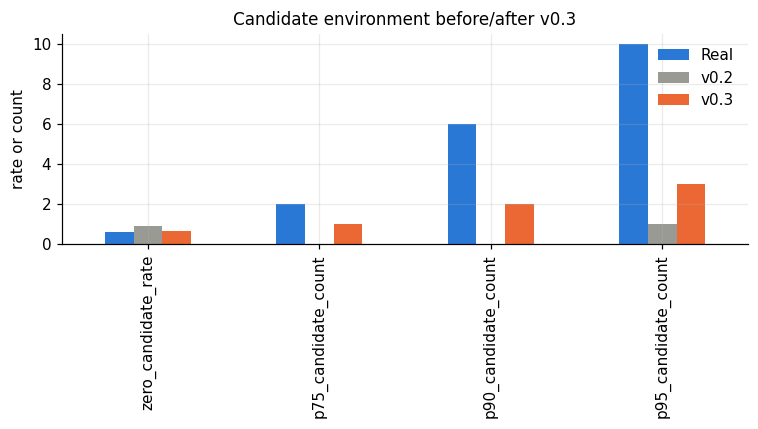

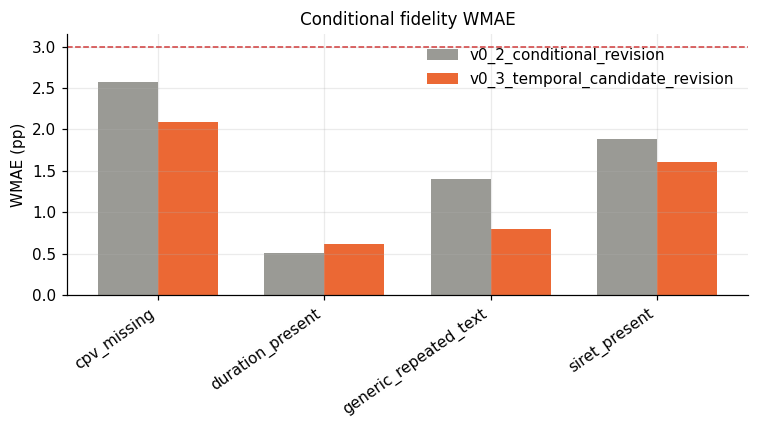

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
summary_plot = candidate_summary_table.set_index("scope").loc[
    ["real_layer1_algorithm_scope", f"{V2}_layer1_algorithm_scope", f"{V3}_layer1_algorithm_scope"],
    ["zero_candidate_rate", "p75_candidate_count", "p90_candidate_count", "p95_candidate_count"],
]
summary_plot.T.plot(kind="bar", ax=ax, color=[COLOR_REAL, COLOR_V2, COLOR_V3])
ax.set_title("Candidate environment before/after v0.3")
ax.set_ylabel("rate or count")
ax.legend(["Real", "v0.2", "v0.3"], frameon=False)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "candidate_environment_before_after.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
wmae_plot = conditional_summary.loc[conditional_summary["version"].isin([V2, V3])]
for version, color in [(V2, COLOR_V2), (V3, COLOR_V3)]:
    sub = wmae_plot[wmae_plot["version"].eq(version)]
    ax.bar(
        np.arange(len(sub)) + (-0.18 if version == V2 else 0.18),
        sub["weighted_mean_abs_error_pp"],
        width=0.36,
        color=color,
        label=version,
    )
ax.set_xticks(np.arange(len(sub)))
ax.set_xticklabels(sub["target"], rotation=35, ha="right")
ax.axhline(ACCEPTANCE["conditional_wmae_pp_max"], color="#d03b3b", linestyle="--", linewidth=1)
ax.set_ylabel("WMAE (pp)")
ax.set_title("Conditional fidelity WMAE")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "conditional_fidelity_v0_2_v0_3_wmae.png", dpi=150)
plt.show()

## Readiness Gate and Report

In [10]:
conditional_status = "PASS" if conditional_summary.loc[conditional_summary["version"].eq(V3), "status"].eq("PASS").all() else "NEEDS_REVISION"
temporal_status = "PASS" if (
    temporal_summary["status"].eq("PASS").all()
    and followup_table.loc[followup_table["horizon_months"].isin([12, 24]), "status"].eq("PASS").all()
) else "NEEDS_REVISION"
candidate_status = "PASS" if candidate_gate.loc[candidate_gate["version"].eq(V3), "status"].eq("PASS").all() else "NEEDS_REVISION"
truth_status = "PASS" if truth_sanity.loc[truth_sanity["status"].ne("DIAGNOSTIC"), "status"].eq("PASS").all() else "NEEDS_REVISION"
overall_status = "READY_FOR_LINKAGE" if all(s == "PASS" for s in [conditional_status, temporal_status, candidate_status, truth_status]) else "NOT_READY_FOR_LINKAGE"

freeze_gate = pd.DataFrame(
    [
        {"dimension": "conditional_fidelity", "status": conditional_status, "notes": "v0.3 WMAE remains under threshold with <=1pp regression vs v0.2."},
        {"dimension": "temporal_validation", "status": temporal_status, "notes": "Calendar and 12m/24m follow-up gates."},
        {"dimension": "candidate_environment_validation", "status": candidate_status, "notes": "Production Layer 1 candidate generation on algorithm source scope."},
        {"dimension": "structural_truth_validation", "status": truth_status, "notes": "Metadata, truth leakage, and broad true-gap tail."},
        {"dimension": "linkage_algorithm_readiness", "status": overall_status, "notes": "Run linking algorithms only if READY_FOR_LINKAGE."},
    ]
)
freeze_gate.to_csv(OUT_TABLES / "temporal_candidate_freeze_gate.csv", index=False)

v3_candidate = candidate_summary_table.set_index("scope").loc[f"{V3}_layer1_algorithm_scope"]
v2_candidate = candidate_summary_table.set_index("scope").loc[f"{V2}_layer1_algorithm_scope"]
report = f"""# Synthetic benchmark v0.3 temporal/candidate revision report

## Result

**Overall status: {overall_status}.**

- Conditional fidelity: **{conditional_status}**
- Temporal validation: **{temporal_status}**
- Candidate environment: **{candidate_status}**
- Structural truth: **{truth_status}**

## Candidate improvement

- Zero-candidate rate: v0.2 {v2_candidate['zero_candidate_rate']:.1%} -> v0.3 {v3_candidate['zero_candidate_rate']:.1%}; real {real_summary['zero_candidate_rate']:.1%}.
- P75/P90/P95 candidates: v0.3 {v3_candidate['p75_candidate_count']:.0f}/{v3_candidate['p90_candidate_count']:.0f}/{v3_candidate['p95_candidate_count']:.0f}; real {real_summary['p75_candidate_count']:.0f}/{real_summary['p90_candidate_count']:.0f}/{real_summary['p95_candidate_count']:.0f}.
- Source-count ratio vs scaled real target: {candidate_gate.query('version == @V3 and dimension == "source_count_ratio"')['value'].iloc[0]:.2f}.
- Cap-reached rate: {v3_candidate['cap_reached_rate']:.1%}.

## Remaining caveats

- The benchmark is credible for running linkage algorithms, but the resulting evaluation is still synthetic-benchmark evidence, not a replacement for inaccessible ground truth.
- Long 60m follow-up remains diagnostic, not a hard blocker for the next linkage stage.
- Linkage-score calibration and threshold optimization were not performed here.

## Artifacts

- `notebooks/10_synthetic_temporal_candidate_revision_validation.ipynb`
- `reports/tables/synthetic_benchmark/v0_3_temporal_candidate_revision/temporal_candidate_freeze_gate.csv`
- `reports/tables/synthetic_benchmark/v0_3_temporal_candidate_revision/candidate_environment_validation_gate_by_version.csv`
- `reports/generated/synthetic_benchmark/v0_3_temporal_candidate_revision_report.md`
"""
OUT_REPORT.write_text(report, encoding="utf-8")
print(report)
freeze_gate

# Synthetic benchmark v0.3 temporal/candidate revision report

## Result

**Overall status: READY_FOR_LINKAGE.**

- Conditional fidelity: **PASS**
- Temporal validation: **PASS**
- Candidate environment: **PASS**
- Structural truth: **PASS**

## Candidate improvement

- Zero-candidate rate: v0.2 90.4% -> v0.3 63.0%; real 60.9%.
- P75/P90/P95 candidates: v0.3 1/2/3; real 2/6/10.
- Source-count ratio vs scaled real target: 1.12.
- Cap-reached rate: 0.0%.

## Remaining caveats

- The benchmark is credible for running linkage algorithms, but the resulting evaluation is still synthetic-benchmark evidence, not a replacement for inaccessible ground truth.
- Long 60m follow-up remains diagnostic, not a hard blocker for the next linkage stage.
- Linkage-score calibration and threshold optimization were not performed here.

## Artifacts

- `notebooks/10_synthetic_temporal_candidate_revision_validation.ipynb`
- `reports/tables/synthetic_benchmark/v0_3_temporal_candidate_revision/temporal_candidat

,dimension,status,notes
0,conditional_fidelity,PASS,v0.3 WMAE remains under threshold with <=1pp r...
1,temporal_validation,PASS,Calendar and 12m/24m follow-up gates.
2,candidate_environment_validation,PASS,Production Layer 1 candidate generation on alg...
3,structural_truth_validation,PASS,"Metadata, truth leakage, and broad true-gap tail."
4,linkage_algorithm_readiness,READY_FOR_LINKAGE,Run linking algorithms only if READY_FOR_LINKAGE.
